<a href="https://colab.research.google.com/github/hanacho-lab/ml-design-experiments/blob/main/03_olist_customer_satisfaction/Olist_Customer_Satisfaction_Delivery_Time_vs_Delivery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Olist Customer Satisfaction: 배송시간 vs. 약속한 배송일 (Delivery Time vs. Delivery Expectation)

### 📚 데이터셋 및 실험 배경

이번 프로젝트에서는 **Olist의 Brazilian E-Commerce Public Dataset**을 사용합니다.

Olist 데이터셋은 브라질 이커머스의 실제 주문 데이터를 익명화하여 공개한 데이터로, 약 10만 건의 주문에 대해 주문 상태, 결제, 배송, 고객 위치, 상품 정보, 리뷰 등을 여러 테이블로 제공합니다. 또한 주문 시점, 실제 배송 완료일, 예상 배송일, 고객 리뷰 점수가 함께 제공되어 배송 경험과 고객 만족도의 관계를 살펴볼 수 있습니다.

🔗 [Brazilian E-Commerce Public Dataset by Olist - Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

일반적으로 배송 성과를 평가할 때는 **실제 배송에 얼마나 오래 걸렸는지**를 먼저 생각하기 쉽습니다.

하지만 고객의 입장에서는 절대적인 배송 기간보다,

> **"처음 안내받은 예상 배송일을 지켰는가?"**

가 만족도에 더 중요한 기준일 수도 있습니다.

따라서 이번 실험에서는 동일한 배송 정보를 두 가지 방식으로 표현하여 비교합니다.

- **Delivery Time** → 주문 후 실제 배송까지 걸린 절대적인 시간
- **Delivery Expectation Gap** → 실제 배송일과 예상 배송일 사이의 차이

이를 통해 단순한 배송 속도와 **고객의 기대 대비 배송 성과** 중 어떤 정보가 낮은 리뷰와 더 강하게 연결되는지 확인합니다.

---

### 📚 Dataset and Experiment Background

This project uses the **Brazilian E-Commerce Public Dataset by Olist**.

The Olist dataset contains anonymized real-world e-commerce transactions from Brazil, with approximately 100,000 orders. It provides multiple perspectives on each order, including order status, payment, delivery, customer location, product information, and customer reviews. In particular, the dataset includes purchase timestamps, actual delivery dates, estimated delivery dates, and review scores, making it well suited for examining the relationship between delivery experience and customer satisfaction.

🔗 [Brazilian E-Commerce Public Dataset by Olist - Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

When evaluating delivery performance, it is natural to focus first on **how long the delivery actually took**.

However, from the customer's perspective, satisfaction may depend less on the absolute delivery duration and more on:

> **"Did the order arrive when it was expected to arrive?"**

Therefore, this experiment represents delivery performance in two different ways:

- **Delivery Time** → the absolute number of days between purchase and actual delivery
- **Delivery Expectation Gap** → the difference between the actual and estimated delivery dates

The experiment compares these two representations to examine whether customer dissatisfaction is more strongly associated with **absolute delivery speed** or with **delivery performance relative to customer expectations**.

---
# 1. 데이터 불러오기 및 확인 (Load and Verify Data)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [ ]:
orders = pd.read_csv('/content/drive/MyDrive/OneInsight Lab/Projects/ML Design Experiments/Olist Customer Satisfaction/Data/olist_orders_dataset.csv')
reviews = pd.read_csv('/content/drive/MyDrive/OneInsight Lab/Projects/ML Design Experiments/Olist Customer Satisfaction/Data/olist_order_reviews_dataset.csv')

In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
orders.shape

(99441, 8)

In [ ]:
reviews.shape

(99224, 7)

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


orders 데이터셋은 모든 변수가 범주형이므로 `describe()`으로 확인하는 것에 의미가 없음

---

All variables in the `orders` dataset are categorical, so checking them with `describe()` is not particularly meaningful.

In [ ]:
reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


### 📊 1차 데이터 확인 요약 (Initial Data Check Summary)

**Orders**

- **데이터 크기**: 총 99,441개의 행과 8개의 열로 구성
- **결측치**: `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` 컬럼에 일부 결측치 존재
- **데이터 타입**
    - 모든 컬럼이 문자형

**Reviews**
- **데이터 크기**: 총 99,224개의 행과 7개의 열로 구성
- **결측치**: `review_comment_title`, `review_comment_message` 컬럼에 많은 결측치 존재
- **데이터 타입**
    - `review_score`: 정수형
    - 나머지 컬럼: 문자형
- **컬럼 분포 (`df.describe()` 기반)**

    `review_score`
    - 평균: 약 4.09
    - 최소값: 1
    - 최대값: 5
    - 대부분의 리뷰 점수가 4점 이상으로 높은 편

---

### 📊 Initial Data Check Summary

**Orders**

- **Dataset size**: 99,441 rows and 8 columns
- **Missing values**: Some missing values are present in `order_approved_at`, `order_delivered_carrier_date`, and `order_delivered_customer_date`
- **Data types**
    - All columns are stored as strings

**Reviews**
- **Dataset size**: 99,224 rows and 7 columns
- **Missing values**: `review_comment_title` and `review_comment_message` contain many missing values
- **Data types**
    - `review_score`: integer
    - All remaining columns: strings
- **Column distribution (based on `df.describe()`)**

    `review_score`
    - Mean: approximately 4.09
    - Minimum: 1
    - Maximum: 5
    - Most review scores are relatively high, with many ratings of 4 or above

# 2. 추가 데이터 확인 및 데이터 전처리 (Additional Data Verification and Preprocessing)

In [ ]:
# 결측치 개수 확인 (Check missing value counts)

orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
# 데이터별 결측치가 있는 컬럼만 추출해 비율을 확인하는 함수 정의 (Define a function to summarize columns with missing values)

def missing_summary(df):
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100

    result = pd.DataFrame({
        "missing_count": missing_count,
        "missing_percent": missing_percent
    })

    return (
        result[result["missing_count"] > 0]
        .sort_values("missing_percent", ascending=False)
    )

In [ ]:
missing_summary(orders)

,missing_count,missing_percent
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


In [ ]:
missing_summary(reviews)

,missing_count,missing_percent
review_comment_title,87656,88.341530
review_comment_message,58247,58.702532


=> `Reviews`의 결측치 비율이 꽤 높은 편임

---

=> The `Reviews` dataset has relatively high missing-value rates in some columns.

### 리뷰 데이터의 `order_id` 중복 확인 (Check Duplicate `order_id` Values in Reviews)

`orders`는 주문당 1행이지만, `reviews`에는 동일 주문에 리뷰가 여러 건 있는 경우가 있을 수 있으니 먼저 확인해봄

---

`orders` contains one row per order, but `reviews` may contain multiple reviews for the same order. Therefore, duplicate `order_id` values are checked first.

In [ ]:
reviews["order_id"].duplicated().sum()

np.int64(551)

In [ ]:
# 중복 주문 확인 (Check duplicate orders)

reviews[reviews["order_id"].duplicated(keep=False)].sort_values("order_id").head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:47
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21 00:00:00,2018-03-22 01:32:08
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19 00:00:00,2017-07-20 12:06:11
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,NaN,NaN,2017-07-14 00:00:00,2017-07-17 13:58:06


In [ ]:
# 특정 중복 주문 예시 확인 (Inspect an example duplicate order)
# reviews[reviews["order_id"] == '029863af4b968de1e5d6a82782e662f5']

이번 프로젝트에서는 주문 하나당 리뷰 하나가 필요한 상황이므로 가장 최근에 작성된 리뷰를 남기는 방식으로 처리

---

This project requires one review per order, so when multiple reviews exist for the same order, only the most recently submitted review is retained.

In [ ]:
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

reviews_clean = (
    reviews
    .sort_values("review_answer_timestamp")
    .drop_duplicates(
        subset="order_id",
        keep="last"
    )
    .copy()
)

### 필요한 컬럼 선택 (Select Required Columns)

In [ ]:
orders_selected = orders[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].copy()

In [ ]:
reviews_selected = reviews_clean[
    [
        "order_id",
        "review_score"
    ]
].copy()

### 주문과 리뷰 데이터 합치기 (Merge Orders and Reviews)

In [ ]:
df = orders_selected.merge(
    reviews_selected,
    on="order_id",
    how="inner"
)

In [ ]:
df.head()

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,4
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,4
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,5
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,5
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,5


### 배송 완료 주문만 골라내기 (Keep Delivered Orders Only)

In [ ]:
df = df[df["order_status"] == "delivered"].copy()

In [ ]:
df["order_status"].value_counts()

,count
order_status,
delivered,95832


### 날짜 데이터 변환 (Convert Date Columns)

In [ ]:
date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [ ]:
# 실제 배송일이나 예상 배송일이 없는 데이터가 있는지 확인 (Check for missing actual or estimated delivery dates)
for col in [
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]:
    count = df[col].isnull().sum()
    percent = df[col].isnull().mean() * 100

    print(
        f"{col}: {count} missing ({percent:.2f}%)"
    )

order_delivered_customer_date: 8 missing (0.01%)
order_estimated_delivery_date: 0 missing (0.00%)


### 필요한 날짜의 결측치 제거 (Remove Missing Values from Required Date Columns)

실제 배송일이나 예상 배송일이 없으면 feature를 계산할 수 없으니 제거

---

Rows without an actual delivery date or estimated delivery date are removed because the delivery-related features cannot be calculated for them.

In [ ]:
df = df.dropna(
    subset=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "review_score"
    ]
).copy()

### **핵심 파생변수 생성 (Create Core Derived Features)**

🚚 `Delivery Time`: 주문 후 실제 배송까지 걸린 일수
- 수식
```math
order_delivered_customer_date - order_purchase_timestamp
```

📦 `Delivery Expectation Gap`: 실제 배송일과 예상 배송일의 차이
- 수식
```math
order_delivered_customer_date - order_estimated_delivery_date
```

---

### **Create Core Derived Features**

🚚 `Delivery Time`: Number of days from purchase to actual delivery
- Formula
```math
order_delivered_customer_date - order_purchase_timestamp
```

📦 `Delivery Expectation Gap`: Difference between the actual delivery date and the estimated delivery date
- Formula
```math
order_delivered_customer_date - order_estimated_delivery_date
```

In [ ]:
# 실제 배송 소요일 생성 (Create delivery time feature)

df["delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.total_seconds() / 86400

In [ ]:
# 예상 배송일 대비 차이 생성 (Create delivery expectation gap feature)

df["delivery_gap"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.total_seconds() / 86400

### 이상치 확인 (Check for Outliers)

추가로 생성된 `delivery_days`와 `delivery_gap` 중 말이 안 되는 데이터 값이 있는지 확인

---

Check whether the newly created `delivery_days` and `delivery_gap` variables contain logically invalid or unusual values.

In [ ]:
# 음수 배송기간이 있는지 확인 (Check for negative delivery durations)

df[df["delivery_days"] < 0]

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score,delivery_days,delivery_gap


In [ ]:
# 두 파생변수의 기술통계 요약 확인 (Review summary statistics for the two derived features)
df[["delivery_days", "delivery_gap"]].describe()

,delivery_days,delivery_gap
count,95824.000000,95824.000000
mean,12.516765,-11.215213
std,9.460505,10.114097
min,0.533414,-146.016123
25%,6.757214,-16.248435
50%,10.206059,-11.973050
75%,15.663542,-6.407182
max,208.351759,188.975081


#### 📌 배송 관련 변수 분포 해석 (Interpretation of Delivery-Related Variables)

`delivery_days`와 `delivery_gap`의 기초 통계량을 확인한 결과, 두 변수 모두 일부 극단값을 포함하고 있음을 확인할 수 있습니다.

**🚚 `delivery_days`**

평균값이 중앙값보다 크고 최대값이 매우 큰 것으로 보아, 일부 주문에서 배송이 상당히 오래 걸린 **우측 꼬리가 긴 분포**가 존재하는 것으로 보입니다.

**📦 `delivery_gap`**

`delivery_gap`은 다음과 같이 해석합니다.

- `delivery_gap < 0` → 예상 배송일보다 일찍 도착
- `delivery_gap = 0` → 예상 배송일과 동일한 날 도착
- `delivery_gap > 0` → 예상 배송일보다 늦게 도착

평균과 중앙값이 모두 음수이므로, 전체적으로는 많은 주문이 **예상 배송일보다 일찍 도착한 경향**을 시사합니다.

반면 최대값이 약 **189일**로 매우 큰 양수이므로, 일부 주문에서는 예상 배송일보다 크게 늦어진 사례도 존재합니다.

#### ✅ 해석 시 주의점
이번 프로젝트에서는 `delivery_gap` 자체가 고객 기대 대비 배송 성과를 나타내는 핵심 변수이므로, 큰 양수나 음수 값을 단순한 이상값으로 간주해 제거하기보다는 우선 유지하는 것이 적절합니다.

특히 극단적인 배송 지연이 낮은 리뷰와 연결될 가능성이 있기 때문에, 이러한 값은 오히려 이번 실험에서 중요한 정보를 포함할 수 있습니다.

---

#### 📌 Interpretation of Delivery-Related Variables

The summary statistics for `delivery_days` and `delivery_gap` show that both variables contain some extreme values.

**🚚 `delivery_days`**

The mean is higher than the median and the maximum is substantially larger than the typical values, suggesting a **right-skewed distribution** in which some orders took unusually long to arrive.

**📦 `delivery_gap`**

`delivery_gap` is interpreted as follows:

- `delivery_gap < 0` → delivered earlier than the estimated date
- `delivery_gap = 0` → delivered on the estimated date
- `delivery_gap > 0` → delivered later than the estimated date

Because both the mean and median are negative, many orders appear to have been **delivered earlier than the estimated delivery date**.

However, the maximum value is approximately **189 days**, indicating that a small number of orders arrived substantially later than expected.

#### ✅ Interpretation Note
In this project, `delivery_gap` is a core variable representing delivery performance relative to customer expectations. Therefore, large positive or negative values are retained rather than automatically removed as outliers.

In particular, extreme delivery delays may be strongly related to low review scores, so these observations may contain important information for the experiment.

### 리뷰 스코어 확인 (Check Review Scores)

In [ ]:
# 리뷰 점수 분포 확인 (Check review score distribution)

df["review_score"].value_counts().sort_index()

,count
review_score,
1,9351
2,2921
3,7916
4,18888
5,56748


In [ ]:
# 분포 비율 확인 (Check distribution proportions)

df["review_score"].value_counts(normalize=True).sort_index()

,proportion
review_score,
1,0.097585
2,0.030483
3,0.082610
4,0.197111
5,0.592211


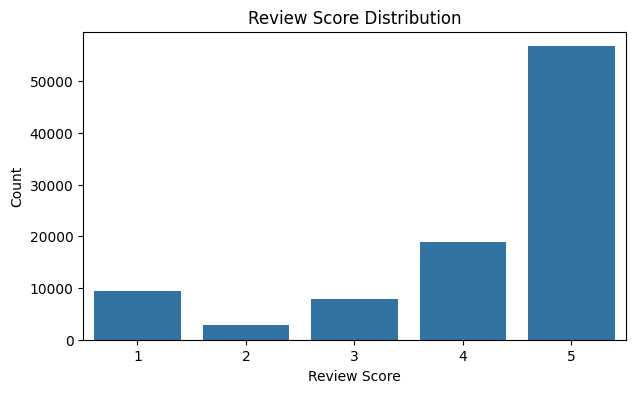

In [ ]:
# 시각화 (Visualization)

plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="review_score"
)

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")

plt.show()

### 리뷰 관련 파생변수 추가 생성 (Create Review-Related Target Variable)

낮은 리뷰에 대해 아래와 같이 정의하고 타겟 변수로 지정합니다.

**정의**
- 1~2점 → Low Review = 1
- 3~5점 → Low Review = 0

---

A binary target variable is created to represent low customer reviews.

**Definition**
- Review score 1–2 → Low Review = 1
- Review score 3–5 → Low Review = 0

In [ ]:
# 타겟 변수 생성 (Create target variable)

df["low_review"] = (df["review_score"] <= 2).astype(int)

In [ ]:
# 비율 확인 (Check proportions)

df["low_review"].value_counts(normalize=True)

,proportion
low_review,
0,0.871932
1,0.128068


=> 높은 평점의 리뷰가 많음

---

=> The dataset contains a large proportion of high-rated reviews.

# 3. 탐색적 데이터 분석 (Exploratory Data Analysis, EDA)

In [ ]:
# 리뷰 점수별 평균 배송기간 (Average delivery time by review score)

df.groupby("review_score")["delivery_days"].mean()

,delivery_days
review_score,
1,21.321699
2,16.643326
3,14.256785
4,12.305974
5,10.680908


In [ ]:
# 리뷰 점수별 평균 예상 배송일 대비 차이 (Average delivery expectation gap by review score)

df.groupby("review_score")["delivery_gap"].mean()

,delivery_gap
review_score,
1,-3.341101
2,-7.933624
3,-10.067979
4,-11.688729
5,-12.684059


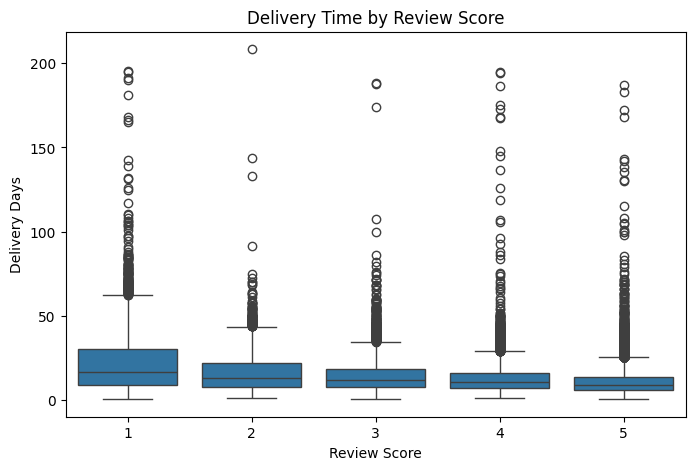

In [ ]:
# 시각화 (Visualization)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="review_score",
    y="delivery_days"
)

plt.title("Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Days")

plt.show()

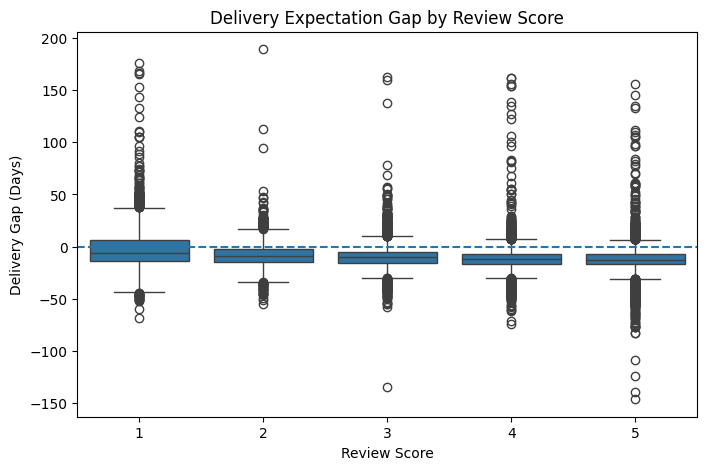

In [ ]:
# 시각화 (Visualization)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="review_score",
    y="delivery_gap"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Delivery Expectation Gap by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Gap (Days)")

plt.show()

# 4. 모델링 (Modeling)

### 데이터 준비 (Prepare Modeling Data)

In [ ]:
X = df[["delivery_days", "delivery_gap"]]
y = df["low_review"]

### 학습 / 테스트 데이터셋 나누기 (Train/Test Split)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
X_train.shape

(76659, 2)

In [ ]:
X_test.shape

(19165, 2)

### 모델 평가 함수 정의 (Define Model Evaluation Function)

In [ ]:
def run_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    features,
    experiment_name
):

    model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ])

    model.fit(
        X_train[features],
        y_train
    )

    y_pred = model.predict(
        X_test[features]
    )

    y_prob = model.predict_proba(
        X_test[features]
    )[:, 1]

    return {
        "Experiment": experiment_name,
        "Features": " + ".join(features),
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_prob
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_prob
        )
    }

### **🧪 실험 A - 실제 배송 소요일을 이용한 예측 (Experiment A - Prediction Using Delivery Time)**

In [ ]:
result_a = run_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    features=["delivery_days"],
    experiment_name="Delivery Time"
)

### **🧪 실험 B — 예상 배송일 대비 차이를 이용한 예측 (Experiment B — Prediction Using Delivery Expectation Gap)**

In [ ]:
result_b = run_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    features=["delivery_gap"],
    experiment_name="Delivery Expectation Gap"
)

### **🧪 실험 C — 두 배송 변수를 함께 이용한 예측 (Experiment C — Prediction Using Both Delivery Features)**

In [ ]:
result_c = run_experiment(
    X_train,
    X_test,
    y_train,
    y_test,
    features=[
        "delivery_days",
        "delivery_gap"
    ],
    experiment_name="Delivery Time + Expectation Gap"
)

### 최종 결과 확인 (Review Final Results)

In [ ]:
results = pd.DataFrame([
    result_a,
    result_b,
    result_c
])

results

,Experiment,Features,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Delivery Time,delivery_days,0.881503,0.725926,0.119804,0.205666,0.68733,0.356972
1,Delivery Expectation Gap,delivery_gap,0.878476,0.757202,0.074980,0.136448,0.65878,0.381992
2,Delivery Time + Expectation Gap,delivery_days + delivery_gap,0.884894,0.762712,0.146699,0.246070,0.68496,0.378991


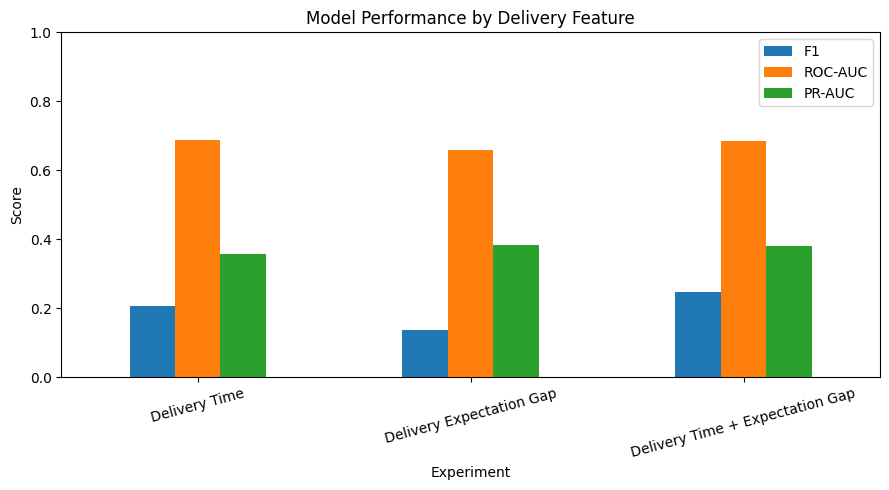

In [ ]:
# 참고 - 성능 비교 그래프 확인 (Reference - Compare model performance visually)

plot_results = results.set_index("Experiment")[
    [
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ]
]

plot_results.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance by Delivery Feature")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend()

plt.tight_layout()
plt.show()

# 📊 최종 결과 해석 (Final Result Interpretation)

세 가지 실험을 비교한 결과, **실제 배송 소요일(`delivery_days`)과 예상 배송일 대비 차이(`delivery_gap`)를 함께 사용한 모델이 기본 분류 임계값 기준으로 가장 좋은 성능**을 보였습니다.

#### 1. 실제 배송 소요일만 사용한 경우
- Accuracy: **0.882**
- F1 Score: **0.206**
- ROC-AUC: **0.687**
- PR-AUC: **0.357**

`delivery_days`만 사용한 모델은 세 실험 중 **가장 높은 ROC-AUC**를 기록했습니다.

이는 실제 배송에 걸린 시간이 고객 불만족을 구분하는 데 일정한 신호를 가지고 있음을 보여줍니다.



#### 2. 예상 배송일 대비 차이만 사용한 경우
- Accuracy: **0.878**
- F1 Score: **0.136**
- ROC-AUC: **0.659**
- PR-AUC: **0.382**

`delivery_gap`만 사용한 모델은 F1과 Recall이 가장 낮았지만, **PR-AUC는 세 모델 중 가장 높았습니다.**

즉, 예상 배송일 대비 실제 배송의 차이가 낮은 리뷰를 구분하는 데 유용한 정보이기는 하지만, 기본 임계값에서는 실제 불만족 고객을 충분히 Positive로 분류하지 못했습니다.

따라서 **좋은 ranking signal을 가지고 있는 것과 기본 threshold에서 좋은 분류 성능을 내는 것은 서로 다른 문제**임을 확인할 수 있습니다.


### 3. 두 배송 변수를 함께 사용한 경우
- Accuracy: **0.885**
- Precision: **0.763**
- Recall: **0.147**
- F1 Score: **0.246**
- ROC-AUC: **0.685**
- PR-AUC: **0.379**

두 변수를 함께 사용한 모델은 세 실험 중:

- 가장 높은 **Accuracy**
- 가장 높은 **Precision**
- 가장 높은 **Recall**
- 가장 높은 **F1 Score**

를 기록했습니다.

이는 고객 불만족이 단순히 **배송이 얼마나 오래 걸렸는가** 또는 **예상 배송일을 지켰는가** 중 하나만으로 설명되기보다는, 두 정보가 서로 보완적으로 작용할 가능성이 있음을 보여줍니다.


### 🔎 주요 해석

처음에는 고객 만족도가 절대적인 배송 시간보다 **예상 배송일 대비 실제 배송 결과**에 더 민감할 것이라고 예상했습니다.

그러나 실험 결과, `delivery_gap` 단독 모델이 모든 지표에서 우수하지는 않았습니다.

오히려:

> **실제 배송 소요일과 고객의 기대 대비 배송 성과를 함께 고려했을 때 가장 안정적인 분류 성능을 얻을 수 있었습니다.**

따라서 이번 실험의 결과는 특정 feature 하나가 다른 feature를 완전히 대체한다기보다, **동일한 배송 경험을 서로 다른 관점으로 표현한 두 변수가 서로 다른 정보를 제공할 수 있다**는 점을 보여줍니다.

또한 세 모델 모두 Precision에 비해 Recall이 매우 낮습니다. 즉, 낮은 리뷰로 예측한 경우에는 비교적 정확하지만 실제 낮은 리뷰 고객의 상당수를 놓치고 있습니다.

따라서 Accuracy만으로 모델을 평가하기보다는 **Recall, F1, ROC-AUC, PR-AUC를 함께 해석하는 것이 중요합니다.**



### 💡 Experiment Takeaway

이번 실험에서는 모델이나 데이터 분할 방식을 변경하지 않고 **feature representation만 변경**했습니다.

그 결과, 동일한 배송 현상이라도 어떤 변수로 표현하느냐에 따라 모델 성능과 평가 지표가 달라졌습니다.

---

The comparison across the three experiments shows that the model using **both absolute delivery time (`delivery_days`) and delivery expectation gap (`delivery_gap`) achieved the strongest classification performance under the default decision threshold**.

#### 1. Delivery Time Only
- Accuracy: **0.882**
- F1 Score: **0.206**
- ROC-AUC: **0.687**
- PR-AUC: **0.357**

The model using only `delivery_days` achieved the **highest ROC-AUC** among the three experiments.

This indicates that the actual time required for delivery contains a meaningful signal for distinguishing customer dissatisfaction.



#### 2. Delivery Expectation Gap Only
- Accuracy: **0.878**
- F1 Score: **0.136**
- ROC-AUC: **0.659**
- PR-AUC: **0.382**

The model using only `delivery_gap` had the lowest F1 Score and Recall, but achieved the **highest PR-AUC** among the three models.

This suggests that the difference between the actual and estimated delivery dates contains useful information for identifying low reviews, but under the default decision threshold it does not classify enough dissatisfied customers as positive.

Therefore, **having a useful ranking signal and achieving strong classification performance at a fixed threshold are not the same thing**.



#### 3. Both Delivery Features
- Accuracy: **0.885**
- Precision: **0.763**
- Recall: **0.147**
- F1 Score: **0.246**
- ROC-AUC: **0.685**
- PR-AUC: **0.379**

The model using both variables achieved the highest:

- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**

among the three experiments.

This suggests that customer dissatisfaction may not be explained by either **absolute delivery speed** or **whether the promised delivery date was met** alone. Instead, the two representations may provide complementary information.



### 🔎 Key Interpretation

The initial hypothesis was that customer satisfaction might be more sensitive to **delivery performance relative to the estimated date** than to absolute delivery duration.

However, the experiment showed that the `delivery_gap`-only model was not superior across all metrics.

Instead:

> **The most stable classification performance was achieved when both actual delivery duration and delivery performance relative to customer expectations were considered together.**

The results therefore suggest that one feature does not simply replace the other. Rather, the two variables represent different aspects of the same delivery experience and may provide complementary predictive information.

All three models also show very low Recall relative to Precision. In other words, when the models predict a low review they are relatively precise, but they still miss many customers who actually gave low ratings.

For this reason, the models should not be evaluated using Accuracy alone. **Recall, F1 Score, ROC-AUC, and PR-AUC should be interpreted together.**



### 💡 Experiment Takeaway

This experiment kept the model and data split fixed while changing only the **feature representation**.

The results demonstrate that even when features originate from the same business process, different representations can lead to different model behavior and evaluation outcomes.